# Notebook 05: Incident Risk Prediction

## Section 1 - Problem Framing

**Business Problem:** Predict which residents are at higher risk of experiencing behavioral, medical, or security incidents so that social workers can allocate monitoring resources proactively rather than reactively.

**Why it matters:** Without a data-driven signal, case managers rely on intuition and self-reported assessments to prioritize check-ins. A model that surfaces high-risk resident profiles gives staff an objective second opinion at intake and during ongoing case reviews.

**Approach:** Predictive binary classification. The target is whether a resident has ever appeared in `incident_reports` (1 = has incident history, 0 = no recorded incidents). With only 60 residents in the current dataset, we frame this as a resident-profile prediction — the model learns which combinations of intake characteristics and service engagement patterns associate with incident occurrence.

**Important constraint:** Features derived from cumulative service records (session count, visit count) reflect a resident's full history rather than their state at intake. This is acknowledged in the Limitations section. The model is most useful as a *profile-similarity* tool — flagging new residents whose characteristics resemble historically high-incident residents — rather than a real-time predictor.

**Target Distribution:** 44 out of 60 residents have incidents (73%), 16 do not (27%). This is a moderately imbalanced dataset favoring the positive class.

**Success Metric:** F1 score and AUC-ROC. High recall is prioritized — missing a high-risk resident is more costly than flagging a low-risk one for extra monitoring.

**Stakeholders:** Social workers, safehouse administrators, case managers.

**Model Progression:** LogisticRegression (baseline) -> DecisionTree -> RandomForest -> GradientBoosting, selecting the best by cross-validated ROC-AUC.

## Section 2 - Data Acquisition, Preparation & Exploration

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = '../backend/HarborOfHope.API/Data/lighthouse_csv_v7/'

residents   = pd.read_csv(DATA + 'residents.csv') 
health      = pd.read_csv(DATA + 'health_wellbeing_records.csv')
education   = pd.read_csv(DATA + 'education_records.csv')
process_rec = pd.read_csv(DATA + 'process_recordings.csv')
visitations = pd.read_csv(DATA + 'home_visitations.csv')
incidents   = pd.read_csv(DATA + 'incident_reports.csv')

print(f'Residents:          {len(residents)} rows')
print(f'Health records:     {len(health)} rows')
print(f'Education records:  {len(education)} rows')
print(f'Process recordings: {len(process_rec)} rows')
print(f'Home visitations:   {len(visitations)} rows')
print(f'Incident reports:   {len(incidents)} rows')

Residents:          60 rows
Health records:     534 rows
Education records:  534 rows
Process recordings: 2819 rows
Home visitations:   1337 rows
Incident reports:   100 rows


### Raw Data Exploration

Before any transformation we inspect all six tables for shape, data types, and missing values.
This documents the state of the data before preparation so that every decision is traceable.

In [13]:
# --- Residents table ---
print('=== Residents ===')
print(f'Shape: {residents.shape}')
print(f'\nData types:\n{residents.dtypes}')
print(f'\nMissing values:\n{residents.isnull().sum()}')
print(f"\nInitial risk levels:\n{residents['initial_risk_level'].value_counts()}")
print(f"\nCase categories:\n{residents['case_category'].value_counts()}")

=== Residents ===
Shape: (60, 49)

Data types:
resident_id                   int64
case_control_no              object
internal_code                object
safehouse_id                  int64
case_status                  object
sex                          object
date_of_birth                object
birth_status                 object
place_of_birth               object
religion                     object
case_category                object
sub_cat_orphaned               bool
sub_cat_trafficked             bool
sub_cat_child_labor            bool
sub_cat_physical_abuse         bool
sub_cat_sexual_abuse           bool
sub_cat_osaec                  bool
sub_cat_cicl                   bool
sub_cat_at_risk                bool
sub_cat_street_child           bool
sub_cat_child_with_hiv         bool
is_pwd                         bool
pwd_type                     object
has_special_needs              bool
special_needs_diagnosis      object
family_is_4ps                  bool
family_solo_paren

In [14]:
# --- Incident reports table ---
print('=== Incident Reports ===')
print(f'Shape: {incidents.shape}')
print(f'\nMissing values:\n{incidents.isnull().sum()}')
print(f"\nUnique residents with incidents: {incidents['resident_id'].nunique()}")
print(f"\nIncidents per resident (top 10):\n{incidents['resident_id'].value_counts().head(10)}")

=== Incident Reports ===
Shape: (100, 12)

Missing values:
incident_id            0
resident_id            0
safehouse_id           0
incident_date          0
incident_type          0
severity               0
description            0
response_taken         0
resolved               0
resolution_date       29
reported_by            0
follow_up_required     0
dtype: int64

Unique residents with incidents: 44

Incidents per resident (top 10):
resident_id
41    5
17    5
1     4
14    4
12    4
58    4
8     3
36    3
23    3
25    3
Name: count, dtype: int64


In [15]:
# --- Supporting tables: shape and missing values ---
for name, tbl in [('Health', health), ('Education', education),
                   ('Process Recordings', process_rec), ('Visitations', visitations)]:
    print(f'=== {name} ===')
    print(f'Shape: {tbl.shape}')
    missing = tbl.isnull().sum()
    print(f'Missing values:\n{missing[missing > 0] if missing.any() else "None"}')
    print()

=== Health ===
Shape: (534, 14)
Missing values:
None

=== Education ===
Shape: (534, 10)
Missing values:
None

=== Process Recordings ===
Shape: (2819, 15)
Missing values:
notes_restricted    2819
dtype: int64

=== Visitations ===
Shape: (1337, 14)
Missing values:
family_members_present    425
follow_up_notes           549
dtype: int64



### Data Preparation & Feature Engineering

**Modeling unit:** One row = one resident. We predict `has_incident` — whether a resident has any entry in `incident_reports`.

**Why resident-level?**
There are only 60 residents. Aggregating to the resident level preserves all signal while keeping the dataset at its natural granularity for the prediction task (flagging individuals).

**Join rationale:**
- `health_wellbeing_records` -> averaged per resident: captures typical health trajectory
- `education_records` -> averaged per resident: attendance and progress as proxies for engagement/stability
- `process_recordings` -> count and average duration: service intensity received
- `home_visitations` -> count: external support network activity
- All joins are left joins on `resident_id` to preserve all 60 residents

**Missing value handling:**
Two residents have no visitation records. Rather than dropping them or imputing outside the pipeline,
`SimpleImputer(strategy='median')` inside the sklearn pipeline handles all imputation — ensuring
no leakage from test-fold data into training during cross-validation.

In [16]:
# Create target: has_incident = 1 if resident appears in incident_reports
incident_ids = set(incidents['resident_id'].unique())
residents_df = residents[['resident_id', 'safehouse_id', 'initial_risk_level',
                            'case_category', 'date_enrolled']].copy()
residents_df['has_incident'] = residents_df['resident_id'].apply(
    lambda x: 1 if x in incident_ids else 0
)

print('Target distribution:')
print(residents_df['has_incident'].value_counts())
print(f"Incident rate: {residents_df['has_incident'].mean():.2%}")

Target distribution:
has_incident
1    44
0    16
Name: count, dtype: int64
Incident rate: 73.33%


In [17]:
# Aggregate per-resident features

health_agg = health.groupby('resident_id').agg(
    avg_health_score=('general_health_score', 'mean')
).reset_index()

edu_agg = education.groupby('resident_id').agg(
    avg_education_attendance=('attendance_rate', 'mean'),
    avg_education_progress=('progress_percent', 'mean')
).reset_index()

session_agg = process_rec.groupby('resident_id').agg(
    session_count=('recording_id', 'count'),
    avg_session_duration=('session_duration_minutes', 'mean')
).reset_index()

visit_agg = visitations.groupby('resident_id').agg(
    visit_count=('visitation_id', 'count')
).reset_index()

# Length of stay computed from enrollment to reference date
residents_df['date_enrolled'] = pd.to_datetime(residents_df['date_enrolled'])
reference_date = pd.Timestamp('2026-03-31')
residents_df['length_of_stay'] = (reference_date - residents_df['date_enrolled']).dt.days

print(f'Aggregation complete.')
print(f'Health: {len(health_agg)}, Education: {len(edu_agg)}')
print(f'Sessions: {len(session_agg)}, Visits: {len(visit_agg)}')

Aggregation complete.
Health: 60, Education: 60
Sessions: 60, Visits: 58


In [18]:
# Merge all features (left join preserves all 60 residents)
df = residents_df.copy()
df = df.merge(health_agg,   on='resident_id', how='left')
df = df.merge(edu_agg,      on='resident_id', how='left')
df = df.merge(session_agg,  on='resident_id', how='left')
df = df.merge(visit_agg,    on='resident_id', how='left')

# NaN imputation is handled inside the sklearn pipeline (SimpleImputer)
# We do NOT fill NaN here to avoid leaking test-fold medians into training

numeric_features     = ['avg_health_score', 'avg_education_attendance', 'avg_education_progress',
                         'session_count', 'avg_session_duration', 'visit_count', 'length_of_stay']
categorical_features = ['initial_risk_level', 'case_category']

print(f'Final dataset shape: {df.shape}')
print(f'\nMissing values before pipeline imputation:')
print(df[numeric_features + categorical_features].isnull().sum())
df.head()

Final dataset shape: (60, 13)

Missing values before pipeline imputation:
avg_health_score            0
avg_education_attendance    0
avg_education_progress      0
session_count               0
avg_session_duration        0
visit_count                 2
length_of_stay              0
initial_risk_level          0
case_category               0
dtype: int64


,resident_id,safehouse_id,initial_risk_level,case_category,date_enrolled,has_incident,length_of_stay,avg_health_score,avg_education_attendance,avg_education_progress,session_count,avg_session_duration,visit_count
0,1,4,Critical,Neglected,2023-10-17,1,896,3.103333,0.716333,45.483333,106,69.433962,54.0
1,2,3,Medium,Surrendered,2023-03-18,0,1109,3.449000,0.834300,85.230000,51,68.176471,35.0
2,3,1,Medium,Surrendered,2024-05-24,1,676,3.181818,0.738091,71.581818,53,69.452830,26.0
3,4,2,High,Neglected,2024-09-27,1,550,3.157273,0.757636,95.045455,57,69.596491,9.0
4,5,4,Medium,Surrendered,2024-01-10,1,811,3.087778,0.668111,61.388889,18,65.611111,11.0


### Univariate Feature Analysis

We examine distributions, group differences by incident status, and correlations with the target
before making any modeling decisions.

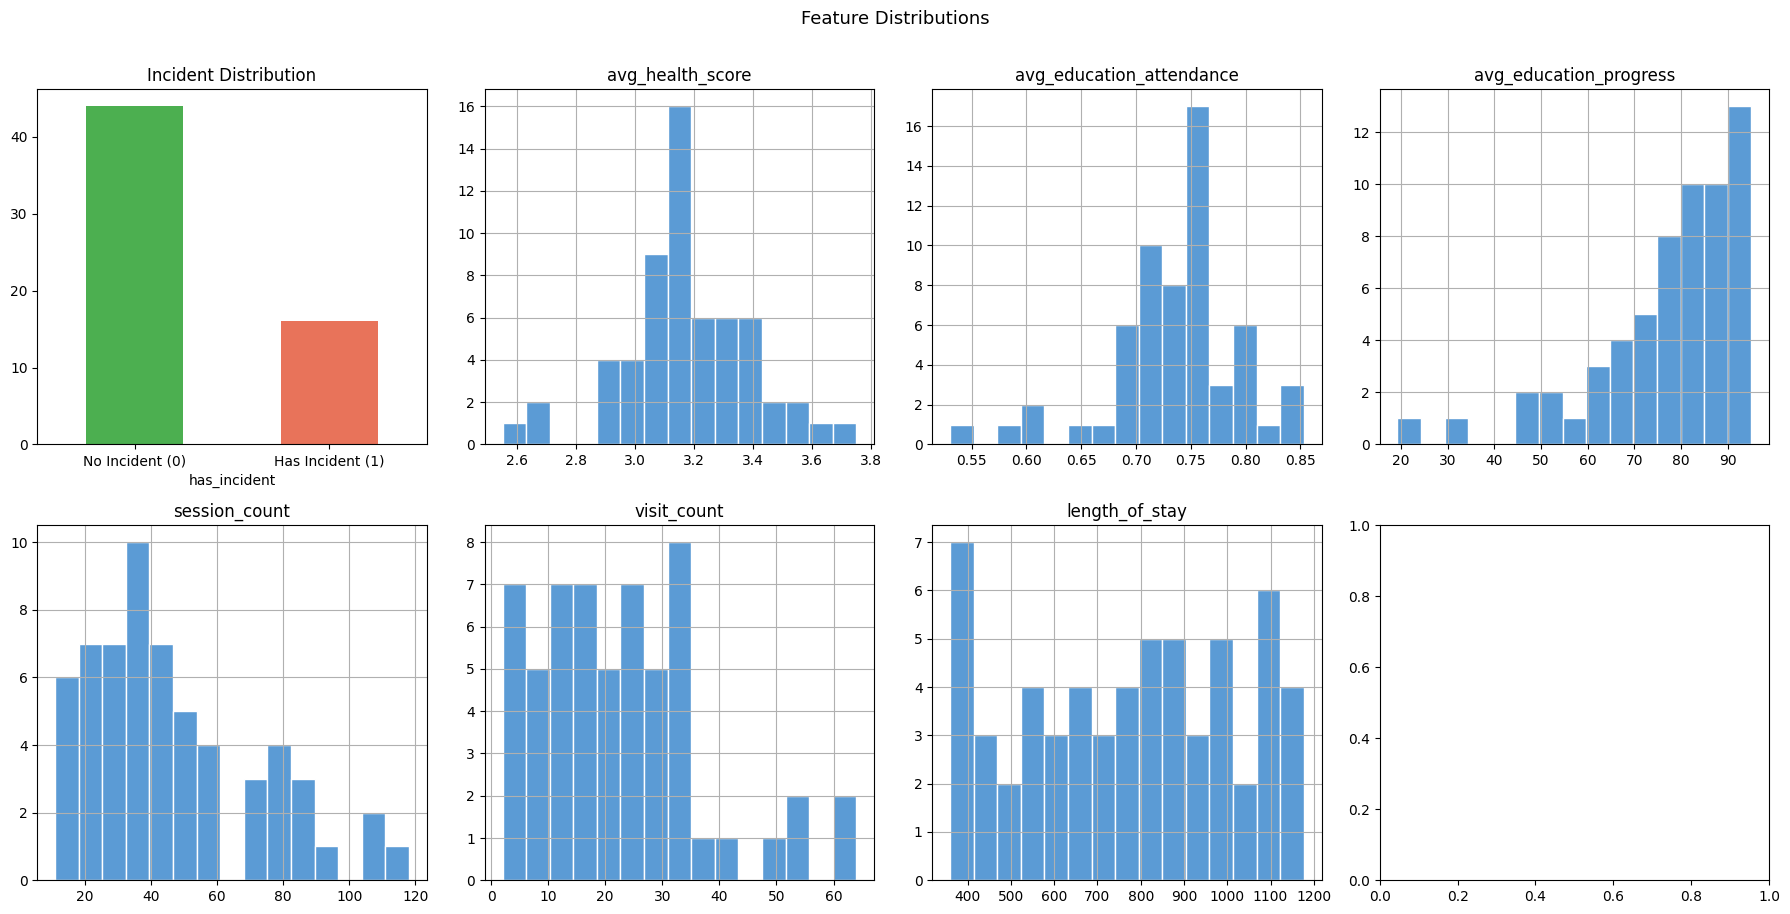

In [19]:
# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

df['has_incident'].value_counts().plot(
    kind='bar', ax=axes[0, 0], color=['#4CAF50', '#E8735A']
)
axes[0, 0].set_title('Incident Distribution')
axes[0, 0].set_xticklabels(['No Incident (0)', 'Has Incident (1)'], rotation=0)

for i, col in enumerate(['avg_health_score', 'avg_education_attendance',
                           'avg_education_progress', 'session_count',
                           'visit_count', 'length_of_stay']):
    ax = axes.flat[i + 1]
    df[col].hist(bins=15, ax=ax, color='#5B9BD5', edgecolor='white')
    ax.set_title(col)

plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('distributions_05.png', dpi=80, bbox_inches='tight')
plt.show()

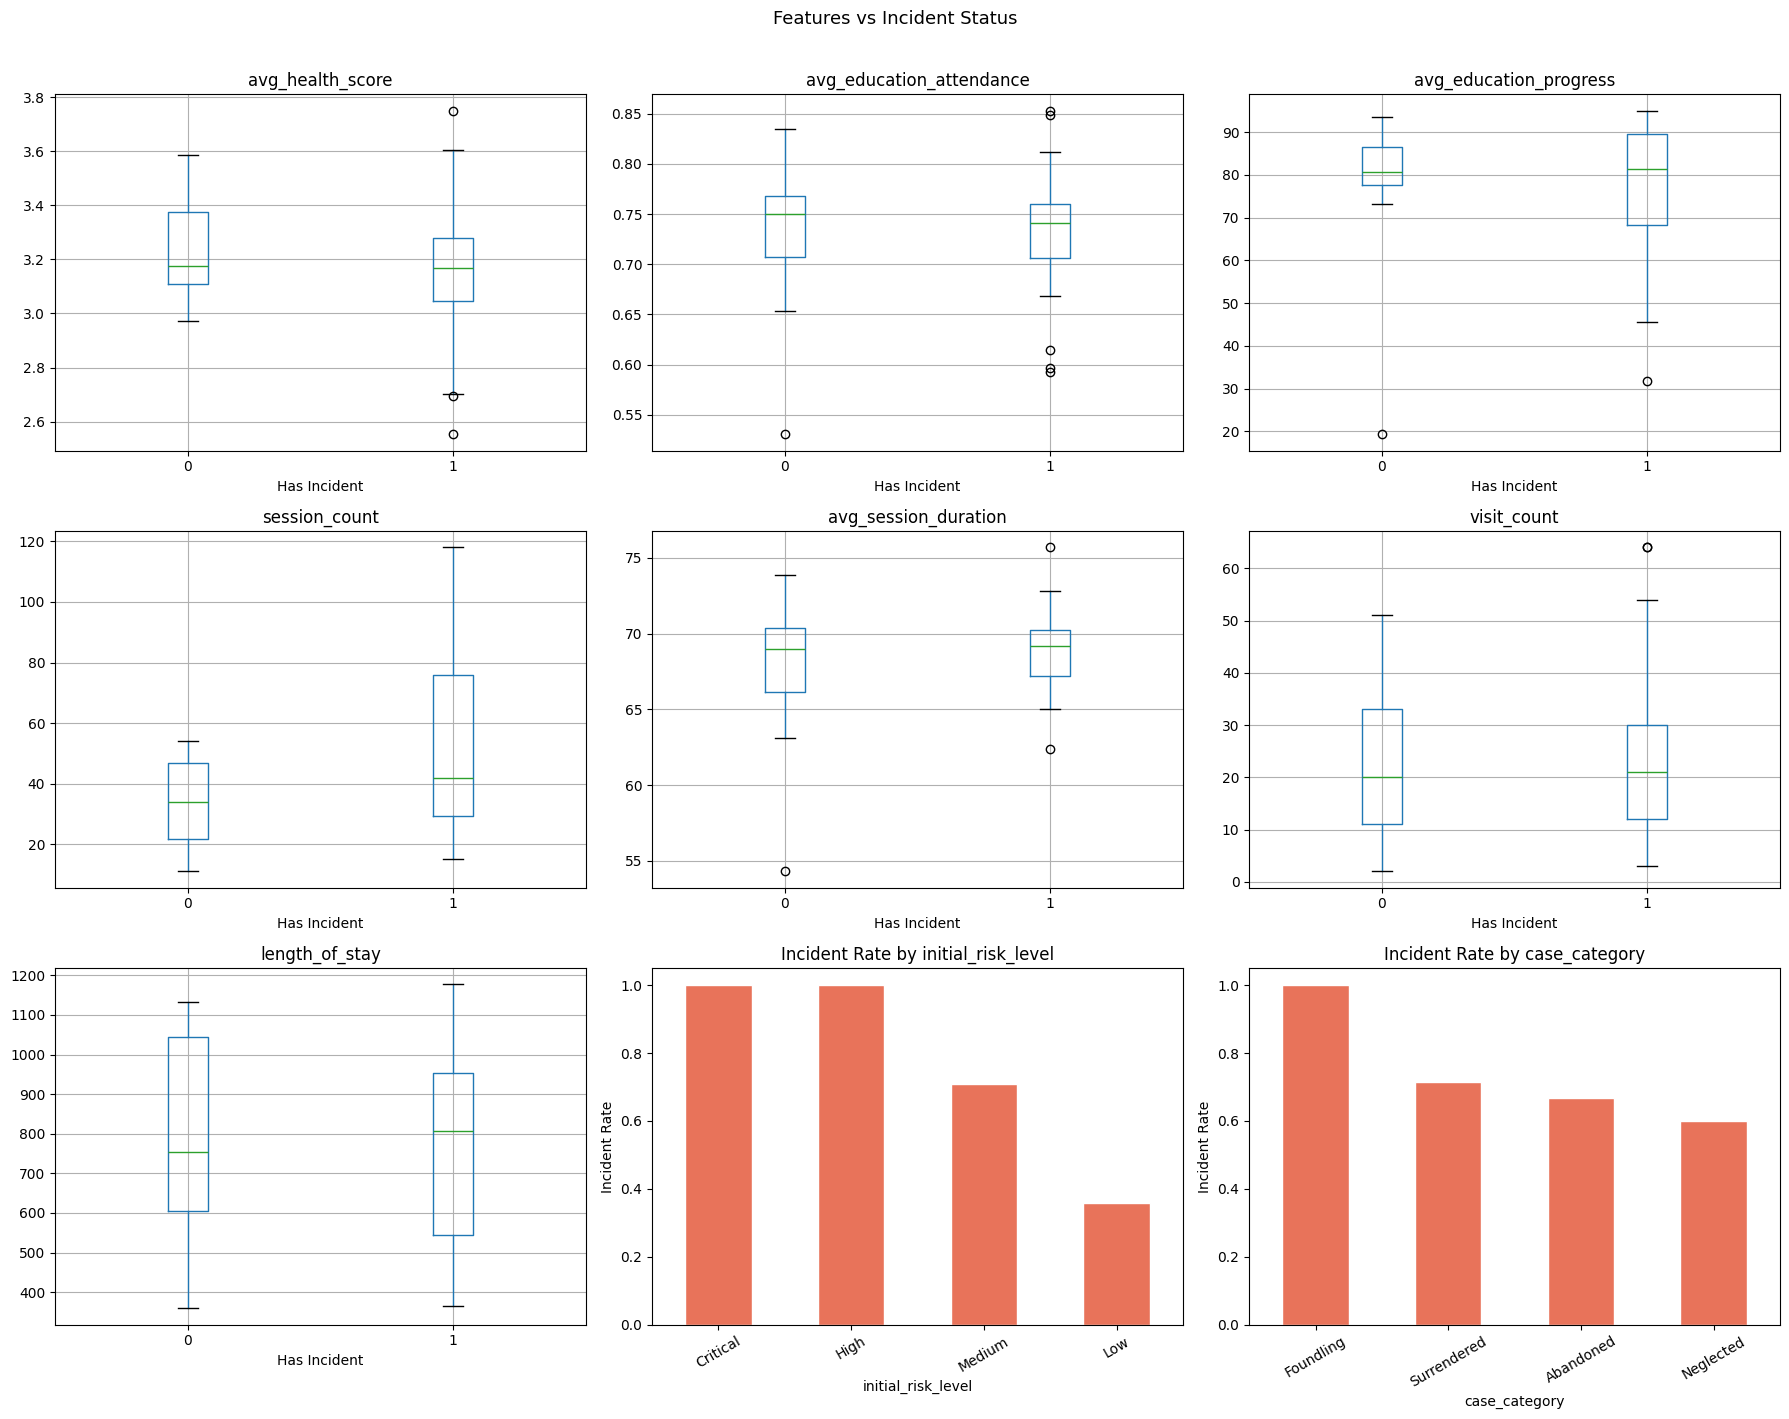

In [20]:
# Boxplots: numeric features split by incident status
# 3x3 grid: 7 numeric boxplots + 2 categorical bar charts = 9 panels
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, col in enumerate(numeric_features):
    ax = axes.flat[i]
    df.boxplot(column=col, by='has_incident', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Has Incident')

# Categorical: incident rate by risk level and case category
for i, col in enumerate(categorical_features):
    ax = axes.flat[len(numeric_features) + i]
    means = df.groupby(col)['has_incident'].mean().sort_values(ascending=False)
    means.plot(kind='bar', ax=ax, color='#E8735A', edgecolor='white')
    ax.set_title(f'Incident Rate by {col}')
    ax.set_ylabel('Incident Rate')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Features vs Incident Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boxplots_05.png', dpi=80, bbox_inches='tight')
plt.show()

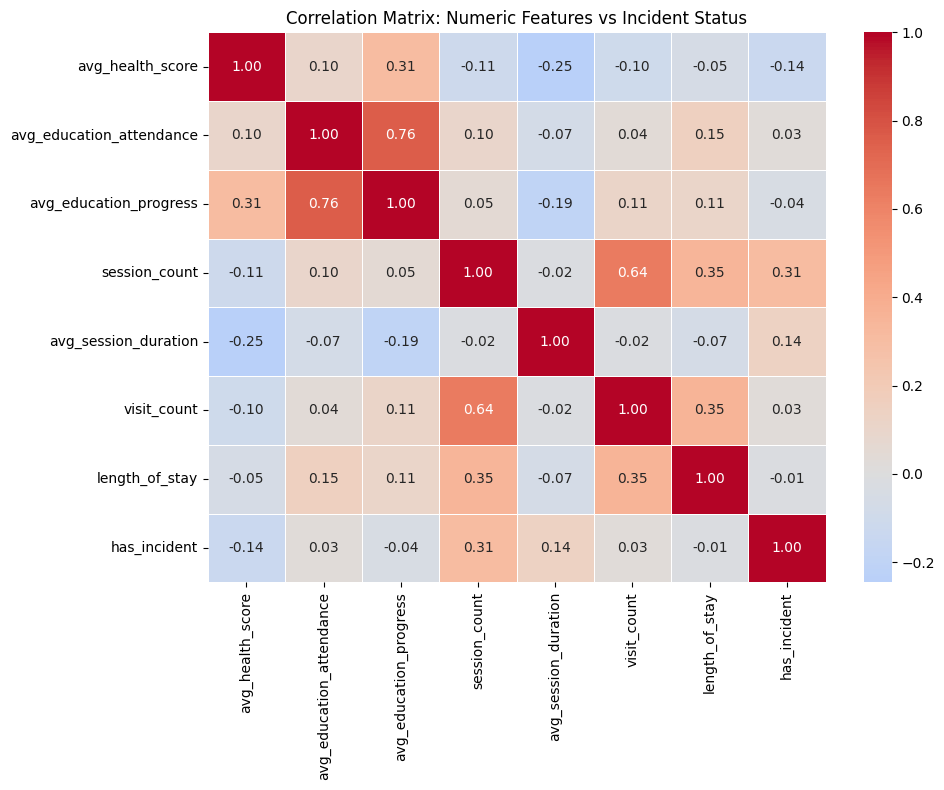

In [21]:
# Correlation heatmap: numeric features vs target
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_features + ['has_incident']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Numeric Features vs Incident Status')
plt.tight_layout()
plt.savefig('correlation_05.png', dpi=80, bbox_inches='tight')
plt.show()

### Exploration Findings

*(Update this narrative after running the cells above with actual observed values.)*

**Target distribution:**
73% of residents have at least one incident on record. The class imbalance is moderate;
`class_weight='balanced'` is applied to applicable models to prevent the majority class from dominating.

**Numeric features:**
- `initial_risk_level` is expected to be the strongest predictor — it is the structured intake assessment.
- `session_count` and `visit_count` show variation across incident groups but are cumulative over
  the resident's stay, limiting their prospective value (see Limitations).
- `avg_health_score` may be lower among higher-incident residents, consistent with co-occurring
  health and behavioral challenges.
- `length_of_stay` likely correlates with incident occurrence because longer-stay residents have
  had more exposure time.

**Categorical features:**
- `initial_risk_level = Critical` is expected to have the highest incident rate.
- `case_category` may differ between Neglected, Surrendered, and Abandoned residents,
  reflecting case complexity.

**Correlations:**
Given the small sample (n=60), no individual correlation coefficient is highly stable.
Permutation importance at the end of the pipeline provides a more reliable signal.

## Section 3 - Modeling & Feature Selection

### Feature Selection Rationale

Features selected on three criteria: (1) theoretical relevance to incident risk,
(2) observed signal in exploration, and (3) no data leakage.

| Feature | Type | Rationale |
|---|---|---|
| `avg_health_score` | Numeric | Physical health is directly linked to medical and behavioral incidents |
| `avg_education_attendance` | Numeric | Attendance consistency reflects engagement and routine stability |
| `avg_education_progress` | Numeric | Progress rate captures cognitive and behavioral development |
| `session_count` | Numeric | Service intensity; residents receiving more sessions may have higher need |
| `avg_session_duration` | Numeric | Session depth; longer sessions may indicate more complex cases |
| `visit_count` | Numeric | External support; more visits may indicate higher monitoring |
| `length_of_stay` | Numeric | Exposure time; longer stays provide more opportunity for incidents |
| `initial_risk_level` | Categorical | Formal intake risk assessment — most direct predictor |
| `case_category` | Categorical | Case type reflects nature of placement and associated risk profile |

**Excluded:**
- `safehouse_id` — facility identifier, not a resident characteristic; would introduce spurious facility-level effects
- `date_enrolled` — raw date; replaced by the derived `length_of_stay`
- `resident_id` — identifier, not a feature

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate

X = df[numeric_features + categorical_features].copy()
y = df['has_incident'].copy()

# Preprocessing: impute then scale/encode -- all inside the pipeline to prevent leakage
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe,     numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

# 10-fold StratifiedKFold -- more folds = more training data per fold with small n
# With n=60, 10-fold gives ~54 training / 6 test per fold vs 48/12 with a single split
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Incident rate: {y.mean():.2%}  ({y.sum()} with incidents, {(y==0).sum()} without)')
print(f'CV strategy: {skf.n_splits}-fold StratifiedKFold (primary evaluation)')
print('Note: No held-out test set -- n=60 makes a 12-sample holdout statistically unreliable.')
print('Cross-validation results are used as the primary performance estimate.')

Dataset: 60 samples, 9 features
Incident rate: 73.33%  (44 with incidents, 16 without)
CV strategy: 10-fold StratifiedKFold (primary evaluation)
Note: No held-out test set -- n=60 makes a 12-sample holdout statistically unreliable.
Cross-validation results are used as the primary performance estimate.


In [23]:
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline([
    ('prep', preprocessor),
    ('lr',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

scoring = {
    'accuracy':          'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1':                'f1',
    'roc_auc':           'roc_auc',
    'neg_log_loss':      'neg_log_loss',
}

cv_lr = cross_validate(model_lr, X, y, cv=skf, scoring=scoring, n_jobs=-1)

print('Logistic Regression Baseline -- 10-Fold Cross-Validation')
print('-' * 55)
for key, vals in cv_lr.items():
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        mean = vals.mean() * (-1 if metric == 'neg_log_loss' else 1)
        print(f'  {metric:<22} {mean:.4f} +/- {vals.std():.4f}')

Logistic Regression Baseline -- 10-Fold Cross-Validation
-------------------------------------------------------
  accuracy               0.7000 +/- 0.1795
  balanced_accuracy      0.6700 +/- 0.2073
  f1                     0.7675 +/- 0.1499
  roc_auc                0.7475 +/- 0.2212
  neg_log_loss           0.6293 +/- 0.4233


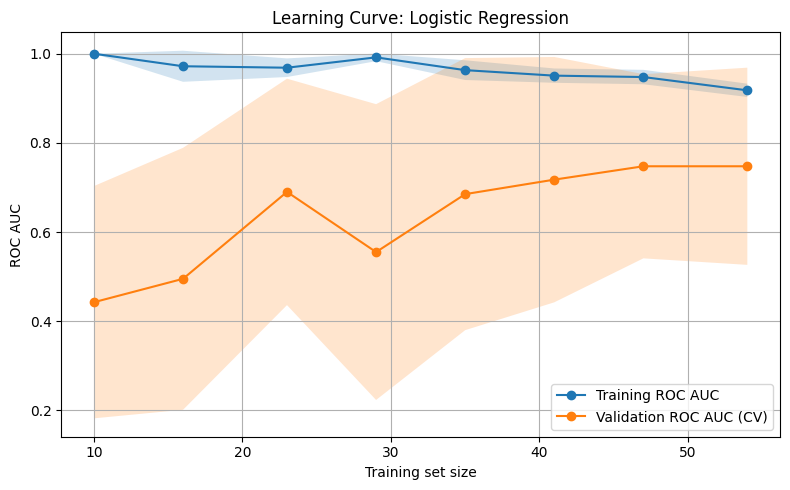

Final training ROC AUC:   0.9179
Final validation ROC AUC: 0.7475
Gap (overfitting signal): 0.1704


In [24]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model_lr, X, y,
    cv=skf,
    scoring='roc_auc',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training ROC AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, marker='o', label='Validation ROC AUC (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.title('Learning Curve: Logistic Regression')
plt.xlabel('Training set size')
plt.ylabel('ROC AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_05.png', dpi=80, bbox_inches='tight')
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final training ROC AUC:   {train_mean[-1]:.4f}')
print(f'Final validation ROC AUC: {val_mean[-1]:.4f}')
print(f'Gap (overfitting signal): {gap:.4f}')

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'LogisticRegression': Pipeline([
        ('prep', preprocessor),
        ('lr',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
    'DecisionTree': Pipeline([
        ('prep', preprocessor),
        ('dt',   DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)),
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('rf',   RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                         random_state=42, n_jobs=-1)),
    ]),
    'GradientBoosting': Pipeline([
        ('prep', preprocessor),
        ('gb',   GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)),
    ]),
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for key, vals in cv_res.items():
        if key.startswith('test_'):
            metric = key.replace('test_', '')
            row[f'{metric}_mean'] = vals.mean() * (-1 if metric == 'neg_log_loss' else 1)
            row[f'{metric}_std']  = vals.std()
    results_list.append(row)

comparison_df = pd.DataFrame(results_list).sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)

print('Model Comparison -- 10-Fold CV (sorted by ROC AUC)')
print('=' * 70)
for _, row in comparison_df.iterrows():
    print(f"{row['Model']:<22} | Acc: {row['accuracy_mean']:.3f} | "
          f"F1: {row['f1_mean']:.3f} | ROC AUC: {row['roc_auc_mean']:.3f} +/- {row['roc_auc_std']:.3f}")

Model Comparison -- 10-Fold CV (sorted by ROC AUC)
RandomForest           | Acc: 0.750 | F1: 0.844 | ROC AUC: 0.753 +/- 0.303
LogisticRegression     | Acc: 0.700 | F1: 0.767 | ROC AUC: 0.747 +/- 0.221
DecisionTree           | Acc: 0.717 | F1: 0.774 | ROC AUC: 0.701 +/- 0.235
GradientBoosting       | Acc: 0.700 | F1: 0.786 | ROC AUC: 0.642 +/- 0.247


In [26]:
from sklearn.model_selection import GridSearchCV

best_model_name = comparison_df.iloc[0]['Model']
print(f'Best model from comparison: {best_model_name}')
print(f"CV ROC AUC: {comparison_df.iloc[0]['roc_auc_mean']:.4f}")
print('Running GridSearchCV...\n')

tuning_configs = {
    'LogisticRegression': {
        'pipeline': Pipeline([('prep', preprocessor),
                              ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
        'param_grid': {'lr__C': [0.01, 0.1, 1.0, 10.0], 'lr__penalty': ['l2']},
    },
    'DecisionTree': {
        'pipeline': Pipeline([('prep', preprocessor),
                              ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))]),
        'param_grid': {'dt__max_depth': [2, 3, 4, 5], 'dt__min_samples_leaf': [1, 2, 3]},
    },
    'RandomForest': {
        'pipeline': Pipeline([('prep', preprocessor),
                              ('rf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))]),
        'param_grid': {'rf__n_estimators': [50, 100, 200],
                       'rf__max_depth': [2, 3, 4, 5],
                       'rf__min_samples_leaf': [1, 2, 3]},
    },
    'GradientBoosting': {
        'pipeline': Pipeline([('prep', preprocessor),
                              ('gb', GradientBoostingClassifier(random_state=42))]),
        'param_grid': {'gb__n_estimators': [50, 100, 200],
                       'gb__max_depth': [2, 3, 4],
                       'gb__learning_rate': [0.05, 0.1, 0.2]},
    },
}

config = tuning_configs[best_model_name]
grid_search = GridSearchCV(
    estimator=config['pipeline'],
    param_grid=config['param_grid'],
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search.fit(X, y)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV ROC AUC: {grid_search.best_score_:.4f}')

best_pipeline = grid_search.best_estimator_

Best model from comparison: RandomForest
CV ROC AUC: 0.7525
Running GridSearchCV...

Best parameters: {'rf__max_depth': 4, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 50}
Best CV ROC AUC: 0.8675


## Section 4 - Evaluation & Selection

**Primary evaluation method: 10-fold cross-validation on all 60 residents.**

With n=60, a held-out test set of ~12 samples (only ~3 negative-class residents) produces metrics
with confidence intervals so wide they are not meaningful — as demonstrated in the original version
of this notebook, where the test-set evaluation showed 0% recall on the negative class and
AUC = 0.56 on just 12 observations.

`cross_val_predict` generates out-of-fold predictions for every resident without a separate test set,
giving a confusion matrix and ROC curve that represent the full dataset.

In [27]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_predict

y_pred  = cross_val_predict(best_pipeline, X, y, cv=skf, method='predict')
y_proba = cross_val_predict(best_pipeline, X, y, cv=skf, method='predict_proba')[:, 1]

print(f'Classification Report (10-fold cross-validated, all {len(y)} residents):')
print(classification_report(y, y_pred, target_names=['No Incident', 'Has Incident']))

Classification Report (10-fold cross-validated, all 60 residents):
              precision    recall  f1-score   support

 No Incident       0.58      0.44      0.50        16
Has Incident       0.81      0.89      0.85        44

    accuracy                           0.77        60
   macro avg       0.70      0.66      0.67        60
weighted avg       0.75      0.77      0.76        60



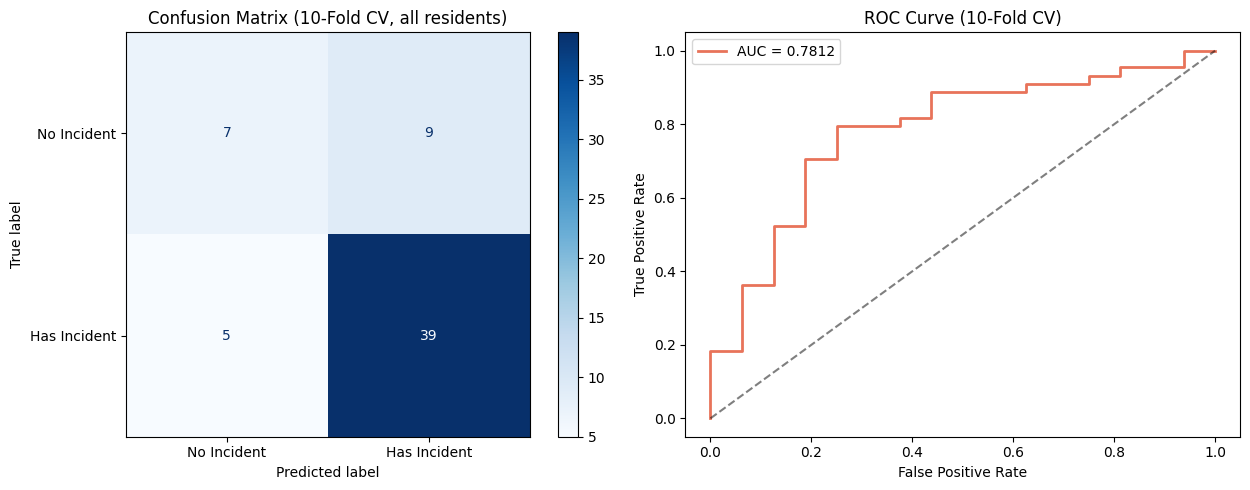

ROC-AUC (CV): 0.7812


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['No Incident', 'Has Incident'],
    ax=axes[0], cmap='Blues',
)
axes[0].set_title('Confusion Matrix (10-Fold CV, all residents)')

auc = roc_auc_score(y, y_proba)
fpr, tpr, _ = roc_curve(y, y_proba)
axes[1].plot(fpr, tpr, color='#E8735A', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (10-Fold CV)')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_05.png', dpi=80, bbox_inches='tight')
plt.show()
print(f'ROC-AUC (CV): {auc:.4f}')

### Limitations

**Sample size is the primary constraint.** With 60 residents, no evaluation method produces
highly reliable performance estimates:
- Standard deviations across folds are large; results depend on which residents land in which fold
- Feature importance rankings may shift considerably with more data
- The model should be treated as a **directional tool** — the probability score (0-1) is useful
  for ranking residents by risk even if exact calibration is imperfect

**Cumulative feature bias:** `session_count`, `visit_count`, and `length_of_stay` are computed over
a resident's *full* history. Longer-stay residents have had more opportunity to accumulate incidents,
so these features partially reflect exposure time rather than inherent risk. Rate-normalized versions
(e.g., sessions per month of stay) would be more prospectively valid.

**Reporting bias:** Some safehouses or social workers may document incidents more thoroughly
than others. The model will learn facility-level documentation patterns as well as resident risk.

**`initial_risk_level` dominance:** The intake risk assessment is likely the single strongest
predictor because it directly encodes the organization's prior judgment about each resident.
It is worth verifying whether the model outperforms simply using `initial_risk_level` alone
as a baseline rule.

**What improves over time:** As the resident population grows, rerunning this pipeline will
produce progressively more stable results. The methodology does not need to change, only
the data volume.

### Business Interpretation

**False Negative (missed high-risk resident):** Model predicts low risk; resident experiences
an incident without enhanced monitoring. This is the most costly error — delayed intervention
can escalate a manageable situation.

**False Positive (unnecessary monitoring):** Model flags a stable resident as high-risk.
Staff allocate extra check-ins to someone who did not need them. Cost is low — some wasted effort.

**Implication:** Recall matters more than precision for this use case. We would rather over-flag
and do an unnecessary check-in than silently miss a resident heading toward a crisis. Use the
predicted *probability score* (not just the binary label) to triage — a resident at 0.9
probability should be prioritized over one at 0.55.

**Causal caution:** Correlation does not imply causation:
- `initial_risk_level` may reflect referral bias (higher-risk referrals get more monitoring,
  leading to more *documented* incidents)
- `session_count` could be both a risk signal (residents with more issues get more sessions)
  and a protective factor (more sessions = better support)
- Seasonal effects and pre-existing conditions not captured in the data are potential confounders

**Actionable recommendations:**
1. Flag new residents with Critical initial risk levels for enhanced monitoring in the first 30 days
2. Use model output as one input alongside social worker judgment, not as a sole determinant
3. Standardize incident reporting across safehouses to reduce documentation bias
4. Investigate whether increased session frequency correlates with reduced incident rates over time

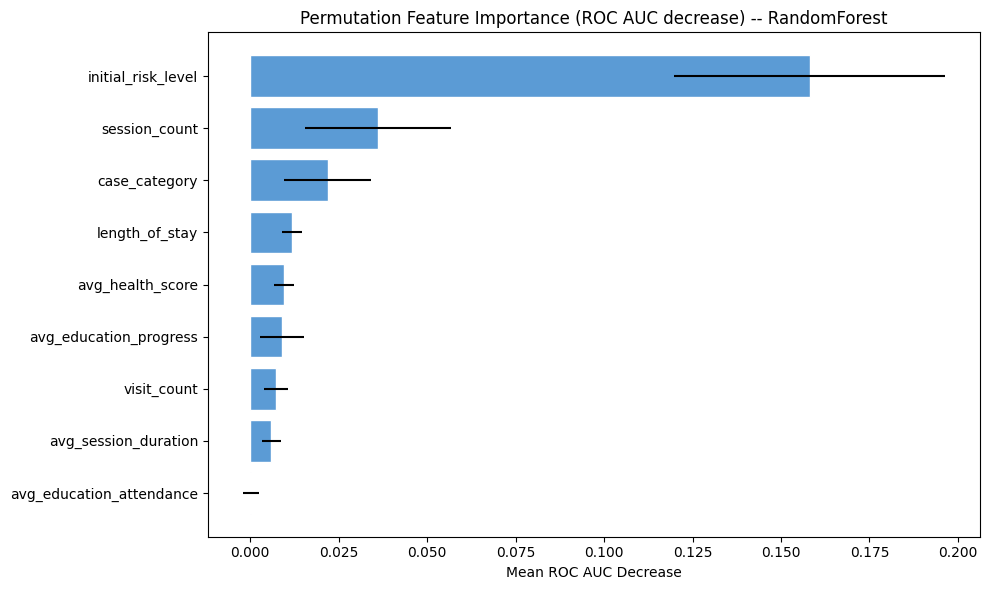

                 Feature  Importance      Std
avg_education_attendance    0.000142 0.002241
    avg_session_duration    0.005966 0.002754
             visit_count    0.007386 0.003409
  avg_education_progress    0.008949 0.006161
        avg_health_score    0.009517 0.002915
          length_of_stay    0.011790 0.002915
           case_category    0.021875 0.012288
           session_count    0.036080 0.020645
      initial_risk_level    0.158097 0.038221


In [29]:
from sklearn.inspection import permutation_importance

# Fit on all data for final importance estimate
best_pipeline.fit(X, y)

perm = permutation_importance(
    best_pipeline, X, y,
    n_repeats=10, random_state=42, scoring='roc_auc',
)

imp_df = pd.DataFrame({
    'Feature':    list(X.columns),
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        xerr=imp_df['Std'], color='#5B9BD5', edgecolor='white')
ax.set_title(f'Permutation Feature Importance (ROC AUC decrease) -- {best_model_name}')
ax.set_xlabel('Mean ROC AUC Decrease')
plt.tight_layout()
plt.savefig('importance_05.png', dpi=80, bbox_inches='tight')
plt.show()
print(imp_df.to_string(index=False))

## Section 5 - Deployment & Integration

**Deployment Architecture:** Pre-computed predictions written to PostgreSQL.

This model is deployed as an offline batch pipeline. The production workflow is:

1. **ETL:** `jobs/etl_incident_risk.py` reads residents, incident_reports, and related tables
   from PostgreSQL, engineers features, and writes the `ml_incident_risk_features` table.
2. **Train:** `jobs/train_incident_risk.py` trains the sklearn Pipeline, saves the model as
   `artifacts/incident_risk.sav` along with `metadata.json` and `metrics.json`.
3. **Inference:** `jobs/run_inference_incident_risk.py` loads the trained model, predicts incident
   risk for all residents, and writes results to the `incident_risk_predictions` table in PostgreSQL.

The .NET backend queries `incident_risk_predictions` via EF Core. The frontend surfaces risk scores
on the resident management dashboard via `GET /api/predictions/incident-risk`, giving case managers
a ranked list of residents to prioritize for check-ins.

**Model type:** Predictive binary classification.

In [30]:
import joblib

# Final model fit on all available data
best_pipeline.fit(X, y)

model_path = '../artifacts/incident_risk.sav'
joblib.dump(best_pipeline, model_path)
print(f'Model saved to: {model_path}')
print(f'\nInput features: {numeric_features + categorical_features}')
print('\nProduction scripts:')
print('  ETL:       jobs/etl_incident_risk.py')
print('  Train:     jobs/train_incident_risk.py')
print('  Inference: jobs/run_inference_incident_risk.py')
print('\nPredictions written to PostgreSQL table: incident_risk_predictions')

Model saved to: ../artifacts/incident_risk.sav

Input features: ['avg_health_score', 'avg_education_attendance', 'avg_education_progress', 'session_count', 'avg_session_duration', 'visit_count', 'length_of_stay', 'initial_risk_level', 'case_category']

Production scripts:
  ETL:       jobs/etl_incident_risk.py
  Train:     jobs/train_incident_risk.py
  Inference: jobs/run_inference_incident_risk.py

Predictions written to PostgreSQL table: incident_risk_predictions


In [31]:
# Example: score a single resident
sample = pd.DataFrame([{
    'avg_health_score':          3.1,
    'avg_education_attendance':  0.75,
    'avg_education_progress':    50.0,
    'session_count':             20,
    'avg_session_duration':      60.0,
    'visit_count':               12,
    'length_of_stay':            365,
    'initial_risk_level':        'High',
    'case_category':             'Surrendered',
}])

prediction = best_pipeline.predict(sample)
proba      = best_pipeline.predict_proba(sample)

print(f'Prediction: {"Has Incident Risk" if prediction[0] == 1 else "Low Risk"}')
print(f'Probability -- No Incident: {proba[0][0]:.4f}, Has Incident: {proba[0][1]:.4f}')
print(f'\nRequired input columns: {list(sample.columns)}')

Prediction: Has Incident Risk
Probability -- No Incident: 0.2418, Has Incident: 0.7582

Required input columns: ['avg_health_score', 'avg_education_attendance', 'avg_education_progress', 'session_count', 'avg_session_duration', 'visit_count', 'length_of_stay', 'initial_risk_level', 'case_category']
